[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KTH-EG2140/course-material/blob/main/notebooks/L01_svedala_warmup.ipynb)

# L1 warm-up — the Svedala grid, again

Welcome to EG2140. This notebook re-runs something most of you did in EG2130: load the Svedala transmission model and solve a power flow. It is *meant* to feel familiar — the point today is to check that everyone can run power system code, not to learn power flow.

**How to run it:** click the *Open in Colab* badge above — the notebook then runs in your browser on Google's machines, nothing installed on your laptop (the proper course environment is built in Lab 1). If you prefer, run it locally in VS Code/Jupyter instead; the first code cell installs what you need either way.

*Did not take EG2130?* Work through the full self-paced exercise at [KTH-EPE/EG2130-SA-Exercise](https://github.com/KTH-EPE/EG2130-SA-Exercise) before Lab 1 — this notebook is the short version.

In [1]:
# Install what this notebook needs (quiet = less output).
# Colab pins pandas==2.2.2 - keep that pin there to avoid a runtime restart;
# locally this installs into your active environment.
import sys
pkgs = "pandapower matplotlib"
if "google.colab" in sys.modules:
    pkgs += " pandas==2.2.2"
%pip install $pkgs --quiet


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


## 1. Load the Svedala model

The grid lives as five CSV files — buses, lines, transformers, generators, loads. You have used these tables for two courses. (Later in this course you will meet the CIM-XML files they were created from.)

In [2]:
import pandas as pd
import pandapower as pp

# The model lives as five CSV tables in a public course repository on Github.
BASE = "https://raw.githubusercontent.com/KTH-EPE/CIM_exportimport/main/Svedala_csv"

# index_col=0: the first CSV column holds each element's ID — lines refer to
# buses BY these IDs, so they must become the DataFrame index, not data.
buses  = pd.read_csv(f"{BASE}/buses.csv", index_col=0)
lines  = pd.read_csv(f"{BASE}/lines.csv", index_col=0)
trafos = pd.read_csv(f"{BASE}/transformers.csv", index_col=0)
gens   = pd.read_csv(f"{BASE}/generators.csv", index_col=0)
loads  = pd.read_csv(f"{BASE}/loads.csv", index_col=0)

# A first sanity look: does the size match what you remember from EG2130?
print(len(buses), "buses |", len(lines), "lines |", len(trafos), "transformers |",
      len(gens), "generators |", len(loads), "loads")
buses.head(3)

52 buses | 52 lines | 44 transformers | 36 generators | 60 loads


,name,vn_kv,type,zone,in_service,geo,origin_id,origin_class,origin_profile,cim_topnode,ConnectivityNodeContainer_id,Substation_id,description,Busbar_id,Busbar_name,GeographicalRegion_id,GeographicalRegion_name,SubGeographicalRegion_id,SubGeographicalRegion_name
0,AGGAN CT11_135.0kV,135.0,b,AGGAN CT11,True,"{""type"": ""Point"", ""coordinates"": [19.827881, 6...",_fcad8062-867d-4020-8b9c-de5924e80357_VL_0_CN,ConnectivityNode,eq,_fcad8062-867d-4020-8b9c-de5924e80357_0,_fcad8062-867d-4020-8b9c-de5924e80357,_ef2904b4-5f04-472b-9d1f-3011a18621dc,NaN,NaN,NaN,_764bc018-fa90-4c17-9fb3-c74e64c7d6c9,Svedala Area,_acd8a17e-855e-4121-ba39-81fe98681553,ZON_NORR
18,AGGAN CT11_400.0kV,400.0,b,AGGAN CT11,True,"{""type"": ""Point"", ""coordinates"": [19.827881, 6...",_1eed5c53-4894-4ace-b0ad-fe0bea6eeccd_VL_0_CN,ConnectivityNode,eq,_1eed5c53-4894-4ace-b0ad-fe0bea6eeccd_0,_1eed5c53-4894-4ace-b0ad-fe0bea6eeccd,_ef2904b4-5f04-472b-9d1f-3011a18621dc,NaN,NaN,NaN,_764bc018-fa90-4c17-9fb3-c74e64c7d6c9,Svedala Area,_acd8a17e-855e-4121-ba39-81fe98681553,ZON_NORR
51,AGGAN CT11_17.0kV,17.0,b,AGGAN CT11,True,"{""type"": ""Point"", ""coordinates"": [20.527881, 6...",_f825d10b-a202-44e8-85d1-e4f78dc3dcf7_VL_0_CN,ConnectivityNode,eq,_f825d10b-a202-44e8-85d1-e4f78dc3dcf7_0,_f825d10b-a202-44e8-85d1-e4f78dc3dcf7,_ef2904b4-5f04-472b-9d1f-3011a18621dc,NaN,NaN,NaN,_764bc018-fa90-4c17-9fb3-c74e64c7d6c9,Svedala Area,_acd8a17e-855e-4121-ba39-81fe98681553,ZON_NORR


## 2. Build the pandapower network

We rebuild the network element by element. One detail worth noticing: the `max_i_ka` column (line current limits) is **empty in the source data**, so we fill in conservative defaults by voltage level. Remember this — it returns later in the course as an example of a data-cleaning decision.

In [3]:
# Start from an empty network and add the elements table by table.
net = pp.create_empty_network(name="Svedala")

# Buses first — everything else attaches to them. index=idx keeps the
# original IDs so the other tables' references still point correctly.
for idx, b in buses.iterrows():
    pp.create_bus(net, vn_kv=b.vn_kv, name=b["name"], zone=b.SubGeographicalRegion_name,
                  in_service=b.in_service, index=idx)

# Line current limits (max_i_ka) are EMPTY in the source data, so we fill
# conservative defaults per voltage level. An assumption, not a measurement!
DEFAULT_I_KA = {400.0: 2.0, 220.0: 1.0, 135.0: 0.9}
for idx, l in lines.iterrows():
    vn = net.bus.at[l.from_bus, "vn_kv"]
    i_ka = l.max_i_ka if pd.notna(l.max_i_ka) else DEFAULT_I_KA.get(vn, 0.5)
    pp.create_line_from_parameters(net, from_bus=l.from_bus, to_bus=l.to_bus,
        length_km=l.length_km, r_ohm_per_km=l.r_ohm_per_km, x_ohm_per_km=l.x_ohm_per_km,
        c_nf_per_km=l.c_nf_per_km, max_i_ka=i_ka, name=l["name"],
        in_service=l.in_service, index=idx)

# Transformers connect the voltage levels (hv_bus/lv_bus).
for idx, t in trafos.iterrows():
    pp.create_transformer_from_parameters(net, hv_bus=t.hv_bus, lv_bus=t.lv_bus,
        sn_mva=t.sn_mva, vn_hv_kv=t.vn_hv_kv, vn_lv_kv=t.vn_lv_kv,
        vk_percent=t.vk_percent, vkr_percent=t.vkr_percent, pfe_kw=t.pfe_kw,
        i0_percent=t.i0_percent, shift_degree=t.shift_degree, name=t["name"],
        in_service=t.in_service, index=idx)

# Generators: p_mw is the dispatch, vm_pu the voltage setpoint. Exactly one
# generator has slack=True — it balances whatever the others do not cover.
for idx, g in gens.iterrows():
    pp.create_gen(net, bus=g.bus, p_mw=g.p_mw, vm_pu=g.vm_pu, sn_mva=g.sn_mva,
        min_q_mvar=g.min_q_mvar, max_q_mvar=g.max_q_mvar, slack=g.slack,
        name=g["name"], in_service=g.in_service, index=idx)

# Loads: active and reactive power demand at their buses.
for idx, ld in loads.iterrows():
    pp.create_load(net, bus=ld.bus, p_mw=ld.p_mw, q_mvar=ld.q_mvar,
        name=ld["name"], in_service=ld.in_service, index=idx)

net

This pandapower network includes the following parameter tables:
   - bus (52 elements)
   - load (60 elements)
   - gen (36 elements)
   - line (52 elements)
   - trafo (44 elements)

## 3. Run the power flow

In [4]:
# Solve the AC power flow (Newton-Raphson under the hood).
pp.runpp(net)

# Results land in net.res_* tables. Losses = what goes in minus what comes out.
print("Converged:", net.converged)
print("Total load:", round(net.res_load.p_mw.sum()), "MW")
print("Losses:", round(net.res_line.pl_mw.sum() + net.res_trafo.pl_mw.sum(), 1), "MW")

Converged: True
Total load: 10981 MW
Losses: 302.8 MW


## 4. Look around

Three quick views: load per zone, the most loaded lines, and the voltage profile.

In [5]:
# Join each load to its bus's zone, then sum per zone.
zl = net.load.merge(net.bus[["zone"]], left_on="bus", right_index=True)
zl["p_mw"] = net.res_load.p_mw          # solved values, not the input table
zl.groupby("zone")["p_mw"].sum().round(0)

zone
ZON_EXTERN     2300.0
ZON_MITT       6111.0
ZON_NORR       1180.0
ZON_SYDVÄST    1390.0
Name: p_mw, dtype: float64

In [6]:
# loading_percent compares the solved current to max_i_ka — the limits we
# filled with defaults above. Keep that in mind when reading these numbers.
top = net.res_line.loading_percent.nlargest(5).to_frame("loading_%")
top["line"] = net.line.loc[top.index, "name"]
top.round(1)

,loading_%,line
15,94.9,RL3
66,94.9,RL4
69,92.3,AL7
77,92.3,AL8
52,86.5,RL8


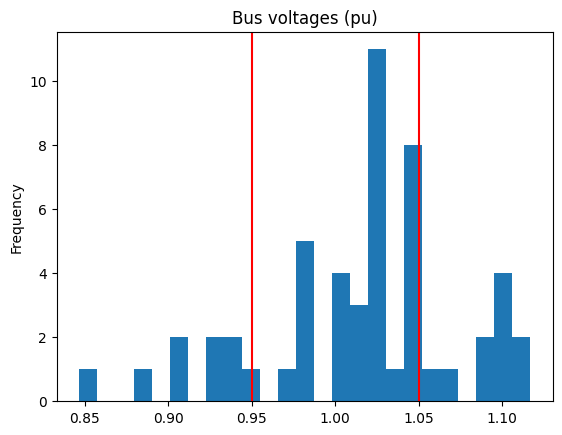

In [7]:
# Histogram of all bus voltage magnitudes; red lines mark the 0.95-1.05 pu band.
ax = net.res_bus.vm_pu.plot(kind="hist", bins=25, title="Bus voltages (pu)")
ax.axvline(0.95, color="r"); ax.axvline(1.05, color="r");

## 5. Three small tasks (10 minutes)

1. **Which lines are loaded above 90%?** How close is this system to its limits in the base case? (Keep this thought: this file is a *stressed planning snapshot* — in a few weeks you will find out exactly how much of this load the grid can carry securely.)
2. **Which buses are outside the 0.95–1.05 pu band?** Use `net.res_bus` together with `net.bus` to name them.
3. **Scale all loads up 5%** (`net.load.scaling = 1.05`), re-run the power flow, and compare the top loadings. What happened to line RL3?

In [8]:
# your work here


## Self-check

Run the cell below. If it prints `ALL OK`, you are done — and your laptop is ready for the course.

In [9]:
# Each assert checks one fact; a clean run prints the last line.
assert net.converged, "power flow did not converge"
assert len(net.bus) == 52 and len(net.line) == 52, "unexpected network size"
assert abs(net.res_load.p_mw.sum() - 10981) < 10, "unexpected total load"
print("ALL OK — see you in Lab 1.")

ALL OK — see you in Lab 1.
